## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - return_rate = f(disclosure,indebtedness,assets,liquidity). Multiple Linear Regression.

This is another use-case for Generalized Linear Models (GLMs), in this case, of type Multiple Linear Regression (MLR). Here, we have a dataset that basically describes some finance metrics of 124 companies. The "return_rate" is a profitability generic metric (either ROE, ROA, stock return, etc) - the dependent variable - that is regressed on disclosure (accountability or transparency), indebtedness (level of debt), assets (in millions of USD), and liquidity (capacity in meeting short-term obligations), the explicative variables. The aim of this project is to show how to diagnose and correct multicollinearity, in order to have a regression model that can be trustful in terms of significance and predictiveness, as well as with a low correlation between the explicative variables themselves. A model should have a high correlation between the explicative variables and the dependent (or target) variable, but a low or no correlation between the predictors. As all variables are quantitative, there's no need for dummyzation. But we'll also deal with adherence of residuals to the Normal, with shapiro-francia test and Box-Cox normalization. Box-Cox not only solves the normalization of residuals, it might also correct multicollinearity between the explicative variables, as well. We also show how to use stepwise method to select predictive variables automatically, not only excluding unsignificant (t) variables from the model, but also eliminating highly-coupled variables, in order to contribute to the reduction or elimination of multicollinearity (along with Box-Cox normalization). Ultimately, we end up with a MLR model that has no multicollinearity, low coupling between its predictor variables, ahderence of residuals to the Normal, and only significant (t) variables compounding the factors of the model expression. We could also have had to do some dummyzations, but, as said, there are no qualitative variables here... but if there were, it would have been done at the beginning. For SLR and other MLR advanced topics, including dummyzation of qualitative variables, check out other examples at this same project directory.

In [2]:
# reading and displaying our dataset
companies_df = pd.read_csv('companies.csv', delimiter=',', encoding="utf-8")
companies_df

,company,return_rate,disclosure,indebtedness,assets,liquidity
0,Adidas,63.67,83,1.3,3967,14.3
1,BASF,55.49,91,33.9,5450,16.8
2,Bayer,52.42,77,36.1,4327,15.5
3,BSH,54.00,90,20.8,4109,16.8
4,Bosch,68.01,93,14.1,4458,17.0
...,...,...,...,...,...,...
119,DuPont,39.85,41,49.5,2996,10.5
120,ExxonMobil,44.16,35,16.8,3622,12.3
121,FedEx,45.38,24,16.1,2972,9.7
122,Ford Motors,45.25,68,34.8,4691,8.9


In [3]:
companies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company       124 non-null    str    
 1   return_rate   124 non-null    float64
 2   disclosure    124 non-null    int64  
 3   indebtedness  124 non-null    float64
 4   assets        124 non-null    int64  
 5   liquidity     124 non-null    float64
dtypes: float64(3), int64(2), str(1)
memory usage: 5.9 KB


In [4]:
companies_df.describe()

,return_rate,disclosure,indebtedness,assets,liquidity
count,124.000000,124.000000,124.000000,124.000000,124.000000
mean,46.195484,49.677419,27.734677,3739.064516,12.300000
std,15.075886,31.338059,12.454287,1538.500462,3.141746
min,21.030000,6.000000,1.200000,1851.000000,7.900000
25%,33.840000,18.000000,18.525000,2597.000000,9.300000
50%,44.175000,41.000000,24.950000,3476.000000,12.200000
75%,58.205000,83.000000,34.125000,4458.000000,15.800000
max,86.180000,98.000000,64.900000,9010.000000,17.000000


Multicollinearity should be minimal or non-existent between explicative variables at the regression of a dependent (target) variable on these predictors. Multicollinearity between explicative variables can turn caotic the analysis of the determinance and significance of explicative variables on the target. The influence of one predictor on the dependent variable may be nullified or augmented by the collinearity of it with other explicative vabriables at that model, and some variables that alone have no correlation at all to the target could start appearing as highly significant at the model, only because of the effect of other explicative variables on that particular predictor. That's why we should always check the correlation of each explicative variable alone, on the target, and not simply believe the t Student tests, when these variables are already at the model, being tested altogether. We may have, tipically, a highly significant F test for the model with not significant t tests for the explicatives variables, also due to multicollinearity - which drops the t significance but have no effect on the F test. We should also be aware of unexpected sign inversions on the regression params (specially betas), that, as far as we know, would make no sense on the relation of that variable to the target (we'd expect a positive beta, and a negative was returned, or vice-versa). If we do not diagnose and resolve multicollinearity before accepting a regression model, that model might end up predicting completely wrong the target values for our dependent variable, and it would be then difficult to detect the artificial and false determinance between the predictors and the target, which would actually be a mere consequence of the effects of the explicative variables between themselves (and not towards the target). In short, we would be working with a wrong and deceptive (misleading) model, which could have disastrous impact.

Some factors that predispose multicollinearity:
- collection of samples at certain ranges, where some of the predictors have maximum collinearity (too concentrated sample);
- small samples (n);
- lagged values on samples (which tend to accumulate correlated info within, and thus generate collinearity risk on variables).

How to objectively detect and confirm multicollinearity:
- High pearson correlation between any of two regressor (X) variables - |corr| > 0.8 is symptomatic;
- Tolerance: < 0.2 → warning, < 0.1 → serious problem;
- VIF (Variance Inflation Factor): VIF = 1 → no multicollinearity; 1–5 → moderate; 5–10 → high (warning); 10 → severe;
- Condition Number / Condition Index (based on eigenvalues of the design matrix, detects hidden multicollinearity, not just 
pairwise): > 30 → moderate issue, 100 → strong;
- Observation of unexpected signs on model params (alfa and/or betas);
- High R2, but insignificant coefficients;
- Large standard errors;
- Coefficients change drastically when adding/removing variables;
- Auxiliary regressions (intuition): if one regressor can be well predicted by others;

You may look for the matricial explanation about why multicollinearity tipically reduces t significance of explicative variables, without altering the F significance test of the whole model - it's out of scope of this project, as it is the matricial calculation of OLS estimators - here, we get them directly from the software. But basically, the t Student test statistics uses, at this context, the diagonal (X'X)$-1$X'Y of the matricial representation of the regression, which may explode in value when multicollinearity happens, and therefore reduces t for the regressors, but has no effect on F.

Tolerance and VIF formulas are displayed below.

![./multicollinearity.png](multicollinearity.png)

In [5]:
# checking pearson correlation between variables
correlation_matrix = companies_df.iloc[:,1:6].corr()
correlation_matrix

,return_rate,disclosure,indebtedness,assets,liquidity
return_rate,1.000000,0.863747,0.004577,0.811349,0.859083
disclosure,0.863747,1.000000,0.136587,0.831343,0.867605
indebtedness,0.004577,0.136587,1.000000,0.228085,-0.081803
assets,0.811349,0.831343,0.228085,1.000000,0.702286
liquidity,0.859083,0.867605,-0.081803,0.702286,1.000000


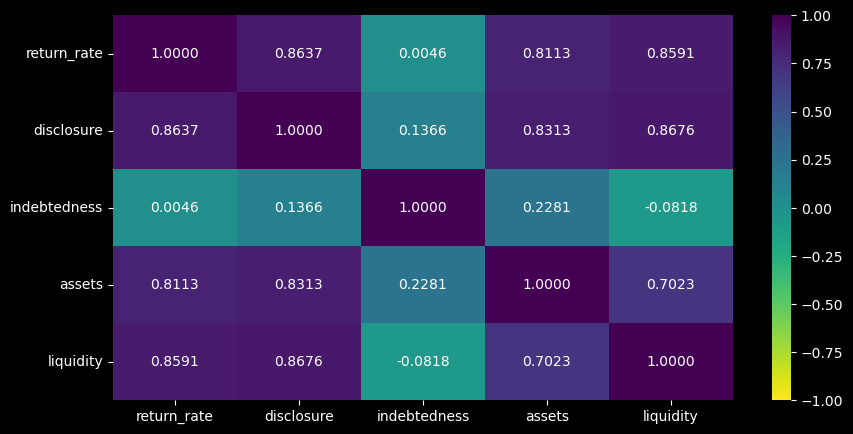

In [6]:
# creating a heatmap graph
plt.figure(figsize=(10, 5))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 10}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=10)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=10)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
plt.show()

In [7]:
# Correlation with significance (p-values) (it should appear below the p-values as stars, pingouin version bug ?)
correlation_matrix2 = pg.rcorr(companies_df, method='pearson',
                              upper='pval', decimals=4,
                              pval_stars={0.01: '***',
                                          0.05: '**',
                                          0.10: '*'})
correlation_matrix2

,return_rate,disclosure,indebtedness,assets,liquidity
return_rate,1.0,0.8637,0.0046,0.8113,0.8591
disclosure,0.8637,1.0,0.1366,0.8313,0.8676
indebtedness,0.0046,0.1366,1.0,0.2281,-0.0818
assets,0.8113,0.8313,0.2281,1.0,0.7023
liquidity,0.8591,0.8676,-0.0818,0.7023,1.0


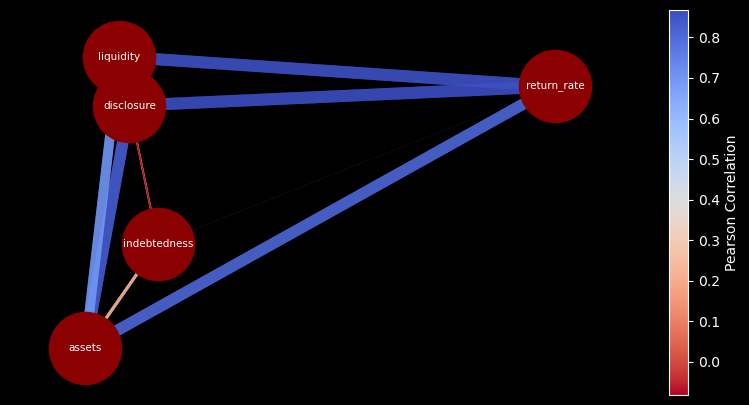

In [8]:
# creating a directed graph showing the correlations (and their magnitudes) between all variables
# Useful when evaluating multicollinearity
plt.figure(figsize=(10, 5))

G = nx.DiGraph()

for variable in correlation_matrix.columns:
    G.add_node(variable)

for i, variable1 in enumerate(correlation_matrix.columns):
    for j, variable2 in enumerate(correlation_matrix.columns):
        if i != j:
            correlation = correlation_matrix.iloc[i, j]
            if abs(correlation) > 0:
                G.add_edge(variable1, variable2, weight=correlation)

correlations = [d["weight"] for _, _, d in G.edges(data=True)]

node_size = 2700

node_color = 'darkred'

cmap = plt.colormaps.get_cmap('coolwarm_r')

edge_widths = [abs(d["weight"]) * 10 for _, _, d in G.edges(data=True)]

pos = nx.spring_layout(G, k=0.75)

pos["return_rate"] = (pos["return_rate"][0] + 1.8, pos["return_rate"][1] + 1.8)
pos["disclosure"] = (pos["disclosure"][0], pos["disclosure"][1] + 1.8)
pos["indebtedness"] = (pos["indebtedness"][0], pos["indebtedness"][1] + 1.8)
pos["assets"] = (pos["assets"][0], pos["assets"][1])
pos["liquidity"] = (pos["liquidity"][0], pos["liquidity"][1] + 1.8)

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=correlations,
                       edge_cmap=cmap, alpha=0.7)

labels = {node: node for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7.5, font_color='white')

ax = plt.gca()
ax.margins(0.1)
plt.axis("off")

smp = cm.ScalarMappable(cmap=cmap)
smp.set_array([min(correlations), max(correlations)])
cbar = plt.colorbar(smp, ax=ax, label='Pearson Correlation')

cbar.set_ticks(np.arange(round(min(correlations),0),
                         max(correlations), 0.1))

plt.show()

<Figure size 2000x1000 with 0 Axes>

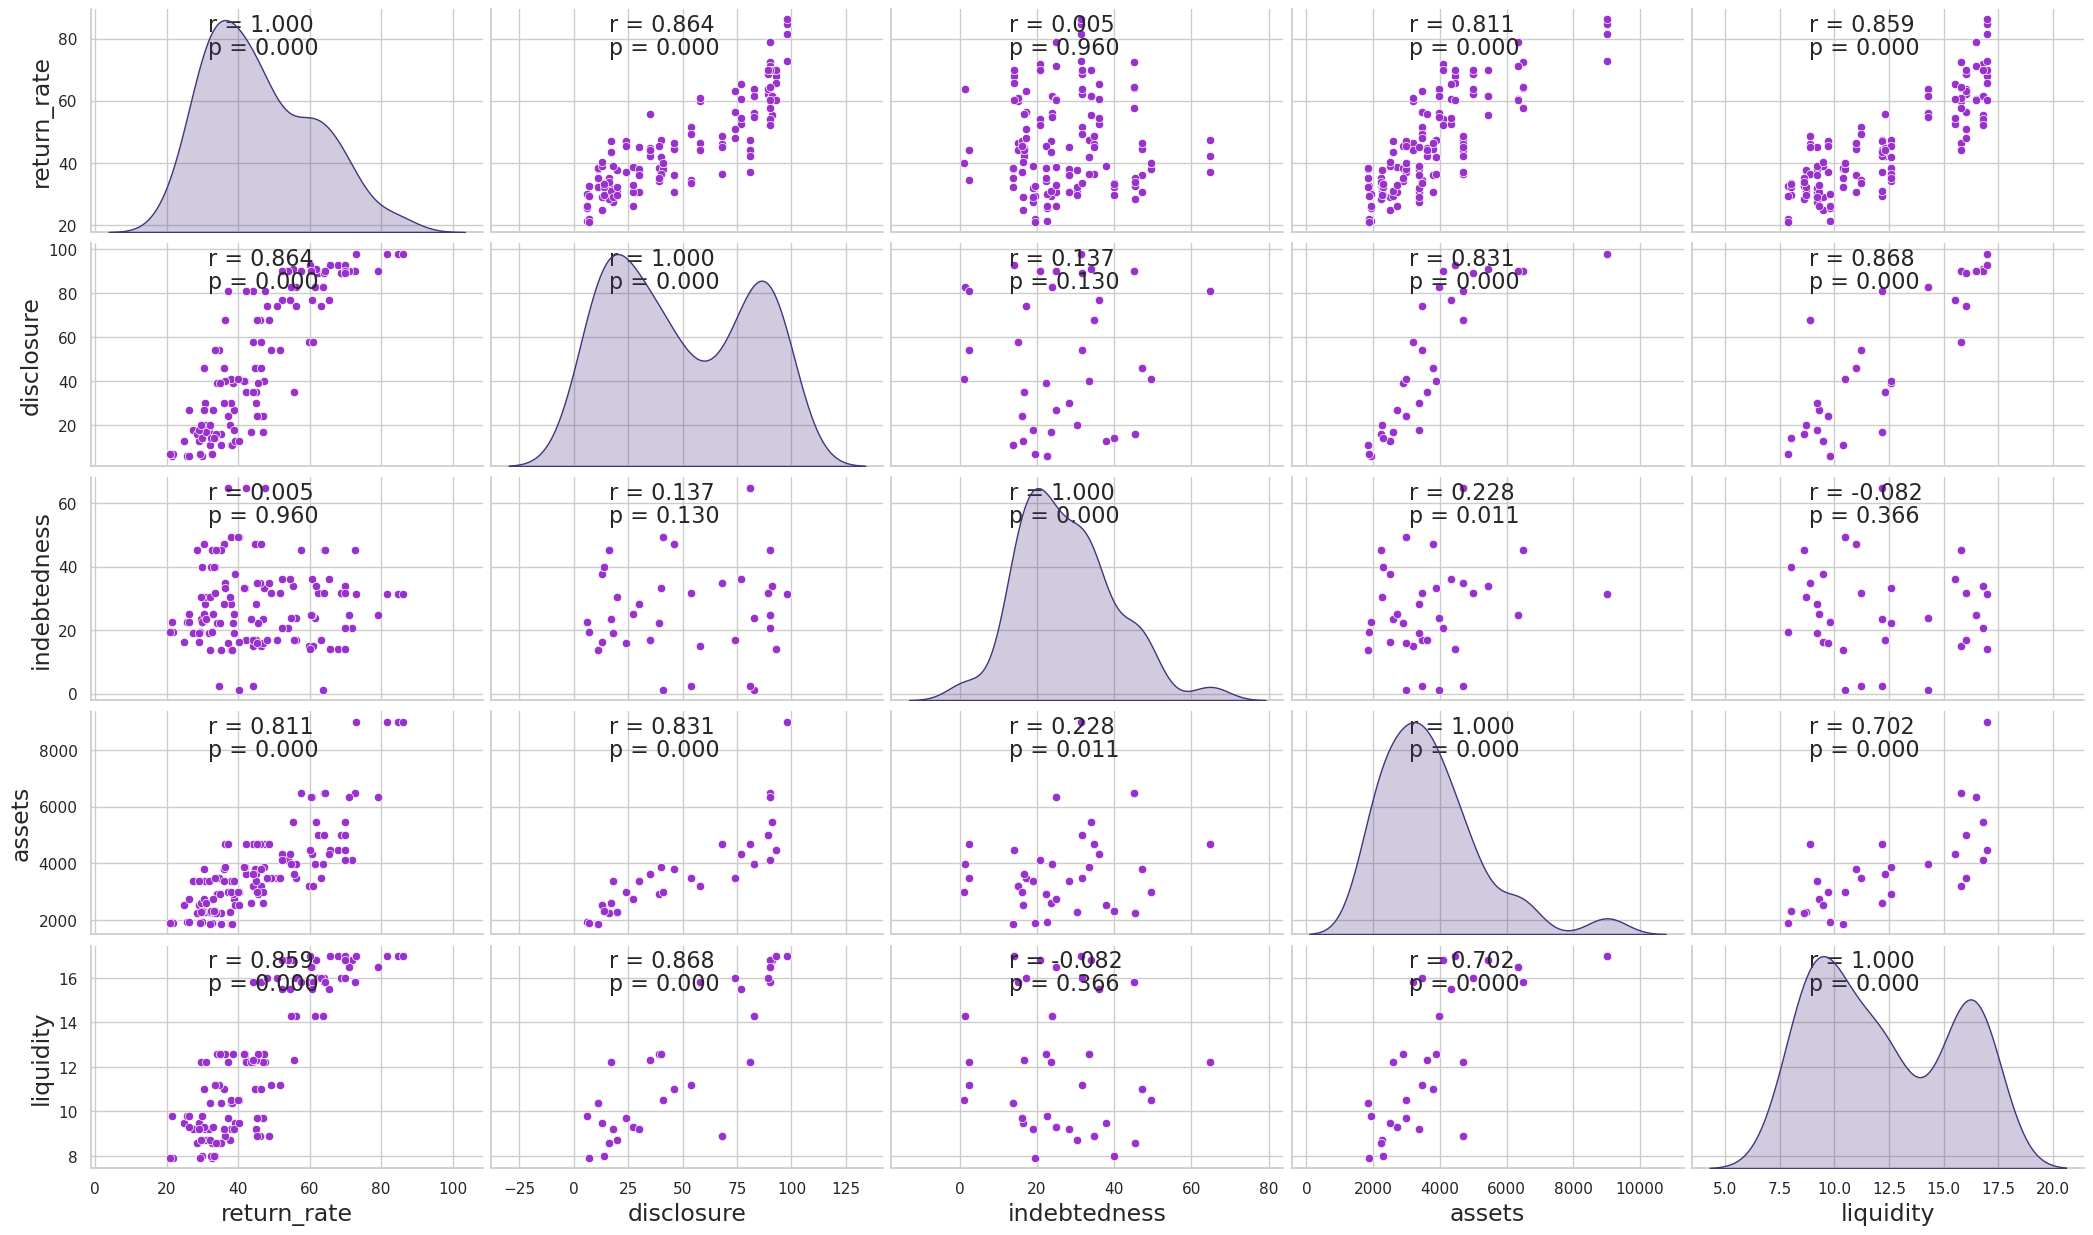

In [9]:
# a graph with scatters, pearson correlation (r) and p-values for each variable pair

def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=16)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=16)

# Configuração do gráfico
sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(companies_df, diag_kind="kde",
                     plot_kws={"color": "darkorchid"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=17)
    ax.set_ylabel(ax.get_ylabel(), fontsize=17)
plt.show()

Observe at the analysis above - correlation matrix, heatmap, directed graph and scatter graph with R2 and p-values - that, when compared two on two, ALL explicative variables have high significant correlations between themselves, except for indebtedness, which has correlation with no other, not even towards the dependent variable. This is a clear sign of multicollinearity between those predictors with high correlation between themselves. We risk creating an OLS model that has all negative disadvantages mentioned before, and that may lead to complete wrong regression results - including misconceptions about the correlations and significance of regressors. Some predictors may falsely lose their importance, while others may falsely gain importance - towards the target, and ultimately this may lead to wrong selection of the regressors we keep at, or discard from, the final model. Let's see below how to resolve it...

In [10]:
# defining an initial regression model, based on the variables and correlations above:
companies_model = sm.OLS.from_formula("return_rate ~ disclosure + indebtedness + assets + liquidity", companies_df).fit()
companies_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            return_rate   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     147.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.35e-45
Time:                        14:13:40   Log-Likelihood:                -401.07
No. Observations:                 124   AIC:                             812.1
Df Residuals:                     119   BIC:                             826.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.0506      4.080      1.483      0.141      -2.028      14.129
disclosure       0.1067      0.048      2.227      0.028       0.012       0.202
indebtedness    -0.0882      0.051     -1.723      0.087      -0.190       0.013
assets           0.0035      0.001      5.134      0.000       0.002       0.005
liquidity        1.9762      0.396      4.987      0.000       1.191       2.761
==============================================================================
Omnibus:                       35.509   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                7.127
Skew:                          -0.136   Prob(JB):                       0.0283
Kurtosis:                       1.858   Cond. No.                     2.94e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.94e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [11]:
# observe, at the summary of the model above, that, as we expected, based on the previous data correlation tests, the F test 
# passed, but the intercept and indebtedness did not pass, considering a 5% significance (alfa) or 95% confidence level. In the 
# case of the alfa (intercept), it should always be kept, never excluded from the model... while, on the case of explicative 
# variables, the ones not significant as regressors, should be eliminated from the model. BUT, as we were suspecting, the 
# Condition number got very high (29400), confirming, along with previous suspicions, the multicollinearity of two or more 
# explicative regressors. So, we can't trust the t tests without first eliminating multicollinearity, in order to have trustful 
# confidence results for each variable... and do the selection accordingly. We may use stepwise method, from statstests, for 
# helping us on the selection. It will iteratively test subsequent model options, recalculating the significance of each variable,
# at each step (iteration), always preserving the alfa, but discarding non-significant betas, returning a model with only 
# significant regressors.

In [12]:
# running stepwise on the model above and getting the new step model
companies_step_model = stepwise(companies_model, pvalue_limit=0.05)
companies_step_model.summary()

Regression type: OLS 

Estimating model...: 
 return_rate ~ Q('disclosure') + Q('indebtedness') + Q('assets') + Q('liquidity')

 Discarding atribute "Q('indebtedness')" with p-value equal to 0.08749071283026183 

Estimating model...: 
 return_rate ~ Q('disclosure') + Q('assets') + Q('liquidity')

 Discarding atribute "Q('disclosure')" with p-value equal to 0.06514029954310716 

Estimating model...: 
 return_rate ~ Q('assets') + Q('liquidity')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('indebtedness')", 'p-value': np.float64(0.08749071283026183)}
{'atribute': "Q('disclosure')", 'p-value': np.float64(0.06514029954310716)}

 Model after stepwise process...: 
 return_rate ~ Q('assets') + Q('liquidity') 

                            OLS Regression Results                            
Dep. Variable:            return_rate   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:           

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            return_rate   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     282.1
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.76e-46
Time:                        14:13:40   Log-Likelihood:                -404.37
No. Observations:                 124   AIC:                             814.7
Df Residuals:                     121   BIC:                             823.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.5348      2.341     -1.083      0.281      -7.169       2.100
Q('assets')        0.0040      0.001      7.649      0.000       0.003       0.005
Q('liquidity')     2.7391      0.258     10.637      0.000       2.229       3.249
==============================================================================
Omnibus:                       23.591   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                5.887
Skew:                          -0.087   Prob(JB):                       0.0527
Kurtosis:                       1.947   Cond. No.                     1.65e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
# At the selection from stepwise, only two regressors remained at the returned model: assets and liquidity. The others were 
# eliminated. Stepwise does not guarantee the absence of multicollinearity, but, it may diminish it a bit. Condition number 
# dropped almost in half, but there is still multicollinearity between the remaining predictors. Observe the inversion of sign
# on the alfa. We should also check if the residuals are normalized. If they're not, we should normalize them, and running
# box-cox might help reduce multicollinearity even more. Principal Component Analysis (PCA) could also be used to maximize 
# variance on ortogonal uncorrelated components, with zero correlation, and therefore eliminate completely multicollinearity.

In [14]:
# testing adherence of residuals of stepwise suggested model to normality through the shapiro-francia method:

sf_test = shapiro_francia(companies_step_model.resid)
sf_test = sf_test.items()
method, statistics_W, statistics_z, p = sf_test
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 # significance level desired
if p[1] > alpha:
	print('H0 not rejected - residuals adherent to normality')
else:
	print('H0 rejected - residuals NOT adherent to normality')

# as we can see below, for a significance level of 5%, or 95% confidance level, H0 is rejected, p<0.05, and therefore the 
# residuals are statistically different from the Normal, thus NOT adherent to its distribution. We must try normalizing the 
# residuals curve, for ex., by using Box-Cox method. And then reassess the normalization of the residuals with shapiro-francia.

method  :  Shapiro-Francia normality test
statistics W  :  0.9738705318499362
statistics z  :  2.0934256948868866
p-value  :  0.01815558534418546
Statistics W=0.97387, p-value=0.018156
H0 rejected - residuals NOT adherent to normality


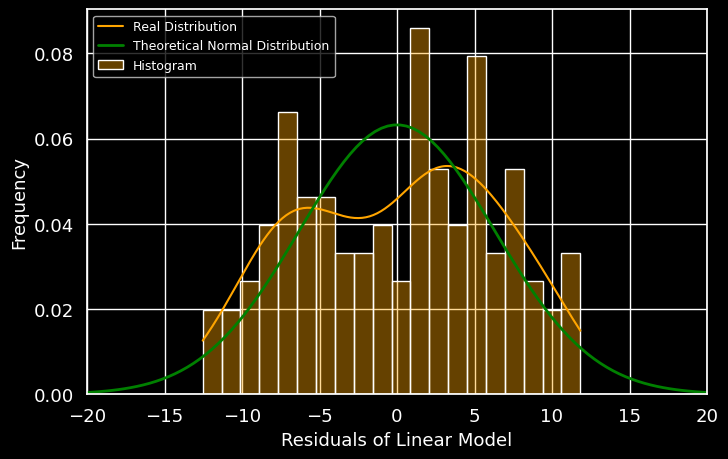

In [15]:
# Analysing the residuals from the model suggested by setepwise method and comparing to the theorical Normal distribution
# Kernel density estimation (KDE) - non-parametric form of estimating probability density function of a certain variable
plt.style.use('dark_background')

# calculating the adjustment values of Normal distribution
(mu, sigma) = norm.fit(companies_step_model.resid)

plt.figure(figsize=(8,5))
sns.histplot(companies_step_model.resid, bins=20, kde=True, stat="density",
             color='orange', alpha=0.4)
plt.xlim(-20, 20)
x = np.linspace(-20, 20, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, color="green", linewidth=2)
plt.xlabel('Residuals of Linear Model', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(['Real Distribution','Theoretical Normal Distribution','Histogram'],
           fontsize=9)
plt.show()

In [16]:
# Observe that, specially at the center of the range of our interpolation, the residuals actually do not adhere to the Normal and 
# have an erratic behaviour. Residuals must be normalized before stepwise method is run. Stepwise does not normalize the residuals.
# Why we should first normalize the data with box-cox, then create an OLS model for it and then perform the stepwise ? Because the 
# normalization of residuals changes the generated box-cox model structurely, including its params. This might alter the 
# significance of the obtained regression params, and therefore the stepwise results might differ, as we're gonna see. And that's
# why box-cox may also help reduce multicollinearity.

In [17]:
# running box-cox on our original data, for then creating a residuals-normalized model and only then run stepwise on it
yast, lmbda = boxcox(companies_df['return_rate'])
print(f"Box-Cox lambda: {lmbda}")

# adding box-cox transformed observed values (Y*i) to our base dataframe. Remember that, after creating the model with these
# box-cox observed values, the results of the regressions (Ŷ*i) will be on the same magnitude, and these results must be 
# transformed back to the original magnitude (Ŷi), for having any real-world meaning
companies_df["return_rate_box_cox"] = yast
companies_df

# calculated lambda is almost 0, which denotes a semi-logarithmic specification

Box-Cox lambda: -0.022564139156469726


,company,return_rate,disclosure,indebtedness,assets,liquidity,return_rate_box_cox
0,Adidas,63.67,83,1.3,3967,14.3,3.965002
1,BASF,55.49,91,33.9,5450,16.8,3.839599
2,Bayer,52.42,77,36.1,4327,15.5,3.787582
3,BSH,54.00,90,20.8,4109,16.8,3.814731
4,Bosch,68.01,93,14.1,4458,17.0,4.024999
...,...,...,...,...,...,...,...
119,DuPont,39.85,41,49.5,2996,10.5,3.536070
120,ExxonMobil,44.16,35,16.8,3622,12.3,3.630464
121,FedEx,45.38,24,16.1,2972,9.7,3.655476
122,Ford Motors,45.25,68,34.8,4691,8.9,3.652843


In [18]:
# defining the OLS model on the box-cox Y*i values, as the dependent variable
companies_box_cox_model = sm.OLS.from_formula('return_rate_box_cox ~ disclosure +\
                                               indebtedness + assets + liquidity', companies_df).fit()
companies_box_cox_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     return_rate_box_cox   R-squared:                       0.801
Model:                             OLS   Adj. R-squared:                  0.795
Method:                  Least Squares   F-statistic:                     119.9
Date:                 Sat, 21 Mar 2026   Prob (F-statistic):           8.80e-41
Time:                         14:13:40   Log-Likelihood:                 74.551
No. Observations:                  124   AIC:                            -139.1
Df Residuals:                      119   BIC:                            -125.0
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.8844      0.088     32.752      0.000       2.710       3.059
disclosure       0.0034      0.001      3.291      0.001       0.001       0.005
indebtedness    -0.0013      0.001     -1.133      0.260      -0.003       0.001
assets        4.331e-05   1.46e-05      2.967      0.004    1.44e-05    7.22e-05
liquidity        0.0359      0.009      4.202      0.000       0.019       0.053
==============================================================================
Omnibus:                        3.781   Durbin-Watson:                   2.177
Prob(Omnibus):                  0.151   Jarque-Bera (JB):                3.267
Skew:                          -0.303   Prob(JB):                        0.195
Kurtosis:                       2.486   Cond. No.                     2.94e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.94e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
# testing box-cox model residuals adherence to the Normal distribution through the shapiro-francia method:

sf_test = shapiro_francia(companies_box_cox_model.resid)
sf_test = sf_test.items()
method, statistics_W, statistics_z, p = sf_test
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 # significance level desired
if p[1] > alpha:
	print('H0 not rejected - residuals adherent to normality')
else:
	print('H0 rejected - residuals NOT adherent to normality')

# as we can see below, for a significance level of 5%, or 95% confidance level, H0 is NOT rejected, p>0.05, and therefore the 
# residuals are statistically equal to the Normal, thus adherent to its distribution.

# we now have a model with a valid F test result and valid t Student results for all predictors, except for indebtedness. And
# still a high Condition number that suggests strong multicollinearity. But now we may proceed with running the stepwise method
# on this current box-cox model, without worrying with residuals normalization - they're are now normalized.

method  :  Shapiro-Francia normality test
statistics W  :  0.9839495666817865
statistics z  :  1.1166580922506897
p-value  :  0.13207027140343985
Statistics W=0.98395, p-value=0.132070
H0 not rejected - residuals adherent to normality


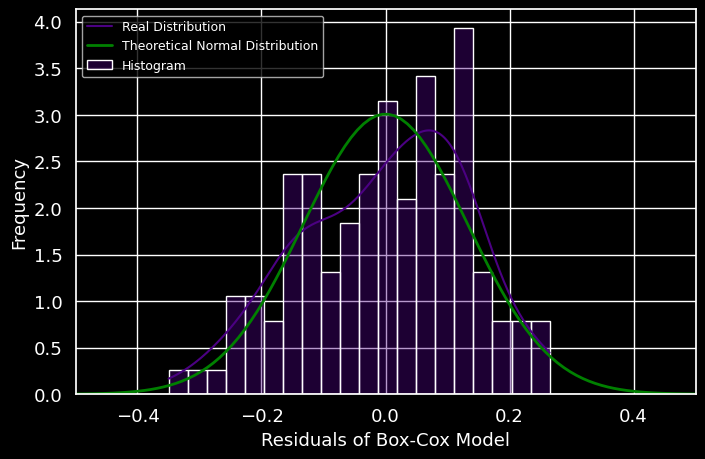

In [20]:
# Analysing the Normal-ahderent residuals from the box-cox model above
plt.style.use('dark_background')

# calculating the adjustment values of Normal distribution
(mu, sigma) = norm.fit(companies_box_cox_model.resid)

plt.figure(figsize=(8,5))
sns.histplot(companies_box_cox_model.resid, bins=20, kde=True, stat="density",
             color='indigo', alpha=0.4)
plt.xlim(-0.5, 0.5)
x = np.linspace(-0.5, 0.5, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, color="green", linewidth=2)
plt.xlabel('Residuals of Box-Cox Model', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(['Real Distribution','Theoretical Normal Distribution','Histogram'],
           fontsize=9)
plt.show()

In [21]:
# observe that, although residuals not perfectly match the Normal, specially at the top-left, they are indeed statistically 
# equal, or normalized, according to the calculated statistics (p-value for W) above. Visually, the residuals now are much
# closer to the Normal than before box-cox normalization. We may proceed with the stepwise method for a final time.

In [22]:
# running stepwise on the box-cox model above and getting the new step box-cox model
companies_step_box_cox_model = stepwise(companies_box_cox_model, pvalue_limit=0.05)
companies_step_box_cox_model.summary()

Regression type: OLS 

Estimating model...: 
 return_rate_box_cox ~ Q('disclosure') + Q('indebtedness') + Q('assets') + Q('liquidity')

 Discarding atribute "Q('indebtedness')" with p-value equal to 0.2596629271283635 

Estimating model...: 
 return_rate_box_cox ~ Q('disclosure') + Q('assets') + Q('liquidity')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('indebtedness')", 'p-value': np.float64(0.2596629271283635)}

 Model after stepwise process...: 
 return_rate_box_cox ~ Q('disclosure') + Q('assets') + Q('liquidity') 

                             OLS Regression Results                            
Dep. Variable:     return_rate_box_cox   R-squared:                       0.799
Model:                             OLS   Adj. R-squared:                  0.794
Method:                  Least Squares   F-statistic:                     159.0
Date:                 Sat, 21 Mar 2026   Prob (F-statistic):           1.21e-41
Time:     

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     return_rate_box_cox   R-squared:                       0.799
Model:                             OLS   Adj. R-squared:                  0.794
Method:                  Least Squares   F-statistic:                     159.0
Date:                 Sat, 21 Mar 2026   Prob (F-statistic):           1.21e-41
Time:                         14:13:40   Log-Likelihood:                 73.887
No. Observations:                  124   AIC:                            -139.8
Df Residuals:                      120   BIC:                            -128.5
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.8275      0.072     39.019      0.000       2.684       2.971
Q('disclosure')     0.0031      0.001      3.109      0.002       0.001       0.005
Q('assets')      4.005e-05   1.43e-05      2.795      0.006    1.17e-05    6.84e-05
Q('liquidity')      0.0398      0.008      5.080      0.000       0.024       0.055
==============================================================================
Omnibus:                        2.714   Durbin-Watson:                   2.071
Prob(Omnibus):                  0.257   Jarque-Bera (JB):                2.472
Skew:                          -0.258   Prob(JB):                        0.290
Kurtosis:                       2.540   Cond. No.                     2.42e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.42e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
# testing step box-cox model residuals adherence to the Normal distribution through the shapiro-francia method:

sf_test = shapiro_francia(companies_step_box_cox_model.resid)
sf_test = sf_test.items()
method, statistics_W, statistics_z, p = sf_test
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 # significance level desired
if p[1] > alpha:
	print('H0 not rejected - residuals adherent to normality')
else:
	print('H0 rejected - residuals NOT adherent to normality')

method  :  Shapiro-Francia normality test
statistics W  :  0.9870486148410434
statistics z  :  0.6866622027236406
p-value  :  0.24614781033076372
Statistics W=0.98705, p-value=0.246148
H0 not rejected - residuals adherent to normality


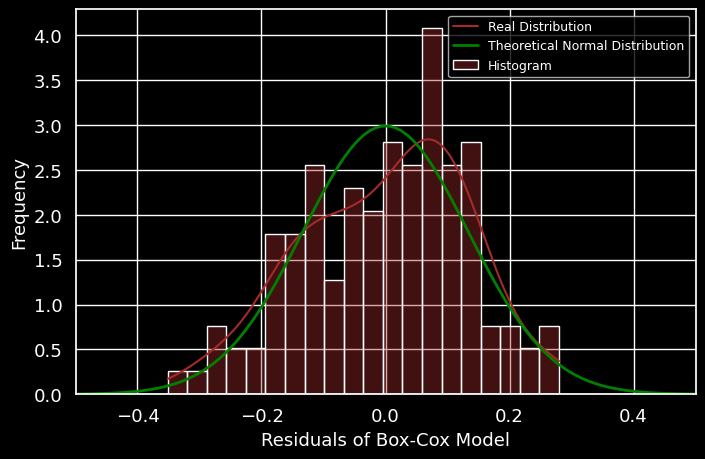

In [24]:
# Analysing the Normal-ahderent residuals from the step box-cox model above
plt.style.use('dark_background')

# calculating the adjustment values of Normal distribution
(mu, sigma) = norm.fit(companies_step_box_cox_model.resid)

plt.figure(figsize=(8,5))
sns.histplot(companies_step_box_cox_model.resid, bins=20, kde=True, stat="density",
             color='brown', alpha=0.4)
plt.xlim(-0.5, 0.5)
x = np.linspace(-0.5, 0.5, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, color="green", linewidth=2)
plt.xlabel('Residuals of Box-Cox Model', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(['Real Distribution','Theoretical Normal Distribution','Histogram'],
           fontsize=9)
plt.show()

In [25]:
# now, after box-cox, and after stepwise on the box-cox residuals-normalized model, the histogram of residuals remains very 
# similar to the one after box-cox, but before stepwise. Statistically, though, we see that, after stepwise, the Condition number
# reduced a bit (along with multicollinearity - which is still present) and the W p-value increased even more, reaffirming the 
# adherence of residuals to the Normal curve.

# The most intersting thing, on this example, is that, when we ran the stepwise, only after box-cox, we managed to keep one of the
# predictors - "disclosure" - that had been eliminated before,for being assumed unsignificant to the target. That is, the removal 
# of such regressor variable from the step model, without box-cox, was wrong, and the not significance of it, at the time, was due 
# to the effect of multicollinearity on it, and not because this predictive variable was actually not significant in predicting 
# the target. So, t Student results on predictors may have unexpected influences from multicollinearity that, without proper 
# analysis, would make us (or the stepwise method) even eliminate very significant and highly correlated regressors - as 
# "disclosure" (see descriptive analysis at the beginning), only because of the effect of multicollinearity on their t values, and 
# not because they're not important to the model. The only variables that should be really removed are those that, individually, 
# had already been suspected to be irrelevant to target predictions (correlation close to zero), and that, even after box-cox and 
# stepwise, kept with a t Student p-value not statistically significant - as in the case of "indebtedness". This, because we were 
# already aware of its null correlation to the target even before defining a valid final model. It may happen, though, that, when
# put together in a same model, some variables may change to significant or unsignificant, regarding predictness of the target, 
# differently from when analysed alone. We should respect that on variables' selection, but being careful to first try to minimize
# at most the multicollinearity with box-cox (if residuals are not normalized) and stepwise, in this order.

In [26]:
# comparing step model without box-cox x step model after box-cox - params are not directly comparable as different magnitudes
# are used
# always do box-cox BEFORE stepwise (when needed, i.e., when residuals are not normalized)
summary_col([companies_step_model, companies_step_box_cox_model],
            model_names=["STEPWISE","STEPWISE AFTER BOX-COX"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs))
        })

,STEPWISE,STEPWISE AFTER BOX-COX
Intercept,-2.5348,2.8275***
,(2.3409),(0.0725)
Q('assets'),0.0040***,0.0000***
,(0.0005),(0.0000)
Q('liquidity'),2.7391***,0.0398***
,(0.2575),(0.0078)
Q('disclosure'),,0.0031***
,,(0.0010)
R-squared,0.8234,0.7990
R-squared Adj.,0.8205,0.7940


In [27]:
# Doing some predictions on the stepwise box-cox model (Ŷ*i). Gotta transform the result back from Ŷ*i to Ŷi.
# - what's the return-rate, on average, for disclosure=50, liquidity=14 and assets=4000 ?

# getting params from the model and printing the regression equation for any input
params = companies_step_box_cox_model.params
terms = [f"{coef:.10f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"return_rate* = {params['Intercept']:.4f} + " + " + ".join(terms)
print(f"Stepwise Box-Cox non-linear normalized model equation:")
print(equation)

# predicting the requested return-rate above from the step box-cox model, in the box-cox magnitude
print(f"\nStepwise Box-Cox non-linear normalized model: return-rate* for disclosure=50, liquidity=14 and assets=4000 is: ")
print(f"{companies_step_box_cox_model.predict(pd.DataFrame({'disclosure':[50],'liquidity':[14],'assets':[4000]}))[0]}")

# transforming the Ŷ*i (return-rate*) above to Ŷi (return-rate), i.e., from box-cox magnitude to original magnitude, by using 
# the inverse of the Y* formula
print(f"\nStepwise Box-Cox non-linear normalized model: return-rate (transformed back) for disclosure=50, liquidity=14 and assets=4000 is:")
print(f"{round((3.7020154366809495 * lmbda + 1) ** (1 / lmbda),2)}")

Stepwise Box-Cox non-linear normalized model equation:
return_rate* = 2.8275 + 0.0031305839*Q('disclosure') + 0.0000400468*Q('assets') + 0.0398402551*Q('liquidity')

Stepwise Box-Cox non-linear normalized model: return-rate* for disclosure=50, liquidity=14 and assets=4000 is: 
3.7020154366809495

Stepwise Box-Cox non-linear normalized model: return-rate (transformed back) for disclosure=50, liquidity=14 and assets=4000 is:
47.74


In [28]:
# adding both step model (unormalized residuals) and step box-cox model (normalized residuals) to the base df for comparison,
# transforming back to the original magnitude, on the latter case
companies_df["return_rate_stepwise_fitted"] = companies_step_model.fittedvalues
companies_df["return_rate_stepwise_box_cox_fitted"] = (companies_step_box_cox_model.fittedvalues * lmbda + 1) ** (1 / lmbda)
companies_df[['company','return_rate','return_rate_stepwise_fitted','return_rate_stepwise_box_cox_fitted']]

,company,return_rate,return_rate_stepwise_fitted,return_rate_stepwise_box_cox_fitted
0,Adidas,63.67,52.590460,54.072393
1,BASF,55.49,65.403203,66.165319
2,Bayer,52.42,57.325376,56.706216
3,BSH,54.00,60.009319,62.161048
4,Bosch,68.01,61.960912,64.337230
...,...,...,...,...
119,DuPont,39.85,38.276327,38.078000
120,ExxonMobil,44.16,45.724617,41.446025
121,FedEx,45.38,35.988530,34.685312
122,Ford Motors,45.25,40.711577,41.929545


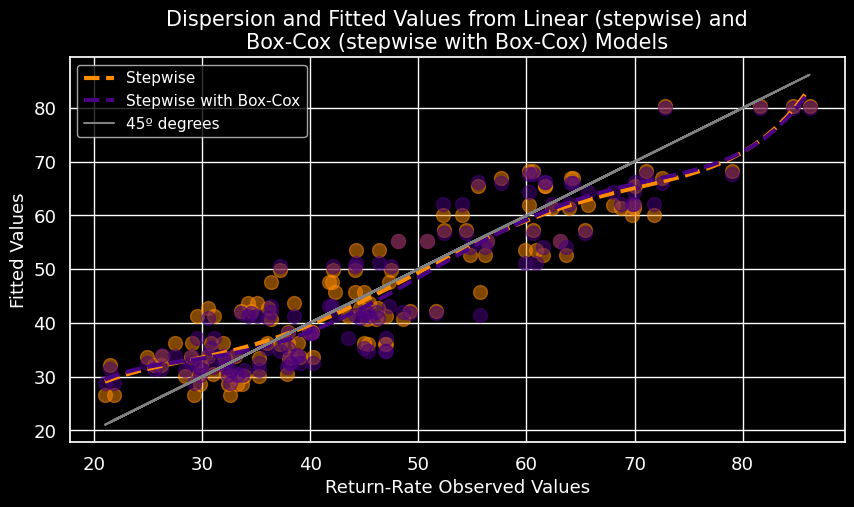

In [29]:
# comparing models graphically: stepwise x stepwise with box-cox
# Here, we're not showing the Y or Ŷ versus predictors, as it would take a 4D graph (1 dependent + 3 preditive variables = 4 axes)
# Here we're showing the sample's results dispersion and predictive Fitted (Ŷ) curves for both models x Observed (Y) values... and
# comparing these to the 45º degree line, which would be the perfect fit (perfect prediction line) for any of the models, as, at 
# this perfect fit line, all predicted values would match exactly the Observed values, with zero residuals
# Although hard to notice, on this particular example and graph, stepwise with box-cox shows a marginally lower dispersion of Ŷ 
# predictions towards the Observed values, when compared to stepwise alone, but effectly guarantees the confidence we need on our
# regression params, as we have the residuals normalized. On other examples, or samples, the differences can be quite larger.

def objective(x, a, b, c, d, e, f):
    return (a * x) + (b * x**2) + (c * x**3) + (d * x**4) + (e * x**5) + f

xdata = companies_df['return_rate']
ydata_linear = companies_df['return_rate_stepwise_fitted']
ydata_bc = companies_df['return_rate_stepwise_box_cox_fitted']

plt.figure(figsize=(10,5))

popt, _ = curve_fit(objective, xdata, ydata_linear)
a, b, c, d, e, f = popt
x_line = np.arange(min(xdata), max(xdata), 1)
y_line = objective(x_line, a, b, c, d, e, f)
plt.plot(x_line, y_line, '--', color='darkorange', linewidth=3)

popt, _ = curve_fit(objective, xdata, ydata_bc)
a, b, c, d, e, f = popt
x_line = np.arange(min(xdata), max(xdata), 1)
y_line = objective(x_line, a, b, c, d, e, f)
plt.plot(x_line, y_line, '--', color='indigo', linewidth=3)

plt.plot(xdata,xdata, color='gray', linestyle='-')
plt.scatter(xdata,ydata_linear, alpha=0.5, s=100, color='darkorange')
plt.scatter(xdata,ydata_bc, alpha=0.5, s=100, color='indigo')
plt.title('Dispersion and Fitted Values from Linear (stepwise) and\nBox-Cox (stepwise with Box-Cox) Models',
          fontsize=15)
plt.xlabel('Return-Rate Observed Values', fontsize=13)
plt.ylabel('Fitted Values', fontsize=13)
plt.legend(['Stepwise','Stepwise with Box-Cox','45º degrees'], fontsize=11)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

In [30]:
# we'll let to show how to calculate Tolerance and VIF, as metrics for diagnosing multicollinearity, on the next project example,
# at this same project directory.